# 2. Histogram Processing


## 2.1. Introduction


A histogram of a digital image with intensity levels in the range $[0, L−1]$ is a discrete function that counts how many pixels in the image have each possible intensity value. It gives a global statistical summary of the brightness distribution meaning you can immediately see whether an image is dark (histogram shifted left), bright (shifted right), low-contrast (narrow peak), or high-contrast (spread wide).

For an 8-bit grayscale image, $L = 256$, so the histogram has $256$ bins, one for each intensity level $r_k = 0, 1, 2, ... 255$.

The unnormalized (raw count) histogram is defined as:

$$
h(r_k) = n_k
$$

Where, <br>
$\qquad r_k =$ Intensity level $k$ $(k = 0, 1, 2, ..., L−1)$ <br>
$\qquad n_k =$ Number of pixels with intensity $r_k$ <br>
$\qquad L =$ Total number of intensity levels ($256$ for 8-bit) <br>

The normalized histogram (probability estimate) is:

$$
p(r_k) = \frac{n_k}{MN}
$$

Where, <br>
$\qquad M =$ Number of rows (image height in pixels) <br>
$\qquad N =$ Number of columns (image width in pixels) <br>
$\qquad MN =$ Total number of pixels in the image <br>

and: $$\sum_{k=0}^{L-1}{p(r_k)} = 1$$


**Program to implement histogram of an image**


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("images/img-2.png", 0)

if img is None:
    print("Image not found!")
    exit()

In [3]:
M, N = img.shape

# calcHist(images, channels, mask, histSize, ranges)
h = cv2.calcHist([img], [0], None, [256], [0, 256])
h = h.flatten()

p = h / (M * N)

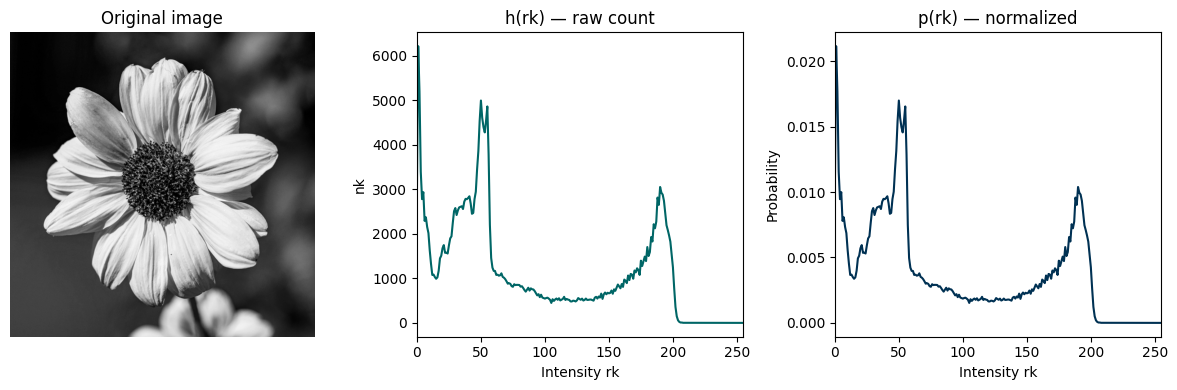

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(h, color="#006666")
plt.title("h(rk) — raw count")
plt.xlim([0, 255])
plt.xlabel("Intensity rk")
plt.ylabel("nk")

plt.subplot(1, 3, 3)
plt.plot(p, color="#003153")
plt.title("p(rk) — normalized")
plt.xlim([0, 255])
plt.xlabel("Intensity rk")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()

## 2.2. Histogram Equalization


Histogram equalization is an automatic contrast enhancement technique that redistributes pixel intensities so that the output histogram is as uniform (flat) as possible across all intensity levels. It works by applying a transformation function derived from the cumulative distribution function (CDF) of the input image's histogram.

The result is an image that uses the full intensity range $[0, L-1]$ more evenly, making dark images brighter and revealing hidden detail in both shadows and highlights.

If $p(r)$ is the probability density of the input intensities, we want a transformation $s = T(r)$ such that the output $p(s)$ is uniform. It can be shown mathematically that this transformation is exactly the CDF of the input:

$$
T(r_k) = (L - 1)\,\mathrm{CDF}(r_k)
$$

which expands to:

$$
s_k = T(r_k) = (L - 1)\sum_{j=0}^{k} p(r_j)
$$

Substituting

$$
p(r_j) = \frac{n_j}{MN},
$$

we obtain:

$$
s_k
=
\left\lfloor
\frac{L - 1}{MN}
\sum_{j=0}^{k} n_j
\right\rfloor
$$


**Program to implement histogram equalization**


In [5]:
img_eq = cv2.equalizeHist(img)

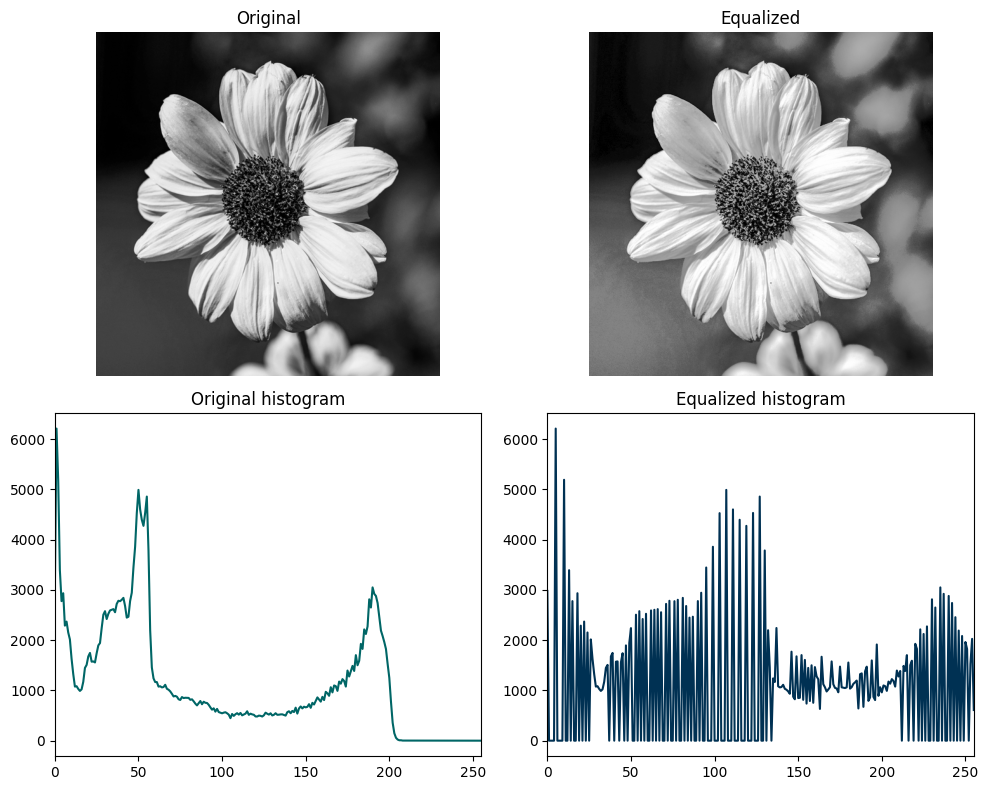

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")
axes[0, 1].imshow(img_eq, cmap="gray")
axes[0, 1].set_title("Equalized")
axes[0, 1].axis("off")

axes[1, 0].plot(cv2.calcHist([img], [0], None, [256], [0, 256]), color="#006666")
axes[1, 0].set_title("Original histogram")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].plot(cv2.calcHist([img_eq], [0], None, [256], [0, 256]), color="#003153")
axes[1, 1].set_title("Equalized histogram")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

## 2.3. Histogram Specification (Matching)


Histogram specification (also called histogram matching) is a technique that transforms an input image so its histogram matches a specified target histogram which can be any desired shape, not just uniform. It is a generalization of histogram equalization: equalization is simply histogram specification where the target is a flat (uniform) histogram.

It is especially useful when you want one image to look like another for example, normalizing lighting conditions across a series of satellite or medical images.

Steps in histogram specification:

1. Equalize the input image

   $$
   s_k = (L − 1) \times \sum_{j=0}^{k}{p_r(r_j)}
   $$

   $\qquad$ Where, $p_r =$ Normalized histogram of the INPUT image

2. Equalize the target (specified) histogram

   $$
   v_k = (L − 1) \times \sum_{j=0}^{k}{p_z(z_j)}
   $$

   $\qquad$ Where, $p_z =$ Normalized histogram of the TARGET (desired) distribution

3. Build the inverse mapping

$\qquad$ For each $s_k$, find the $z$ that gives the closest $v$ such that $|v_z − s_k|$ is minimum:

$$
\text{mapping}(r_k) = z
$$

$\qquad$ Final output pixel value for input intensity $r_k$:

$$
output(r_k) = mapping(r_k)
$$


In [7]:
def hist_specify(src, ref):
    L = 256

    h_src = cv2.calcHist([src], [0], None, [L], [0, L]).flatten()
    cdf_src = np.cumsum(h_src / h_src.sum())

    h_ref = cv2.calcHist([ref], [0], None, [L], [0, L]).flatten()
    cdf_ref = np.cumsum(h_ref / h_ref.sum())

    lut = np.zeros(L, dtype=np.uint8)
    for s in range(L):
        diff = np.abs(cdf_ref - cdf_src[s])
        lut[s] = np.argmin(diff)

    return lut[src]

In [8]:
src = cv2.imread("images/img-2.png", 0)
ref = cv2.imread("images/img-1.png", 0)

result = hist_specify(src, ref)

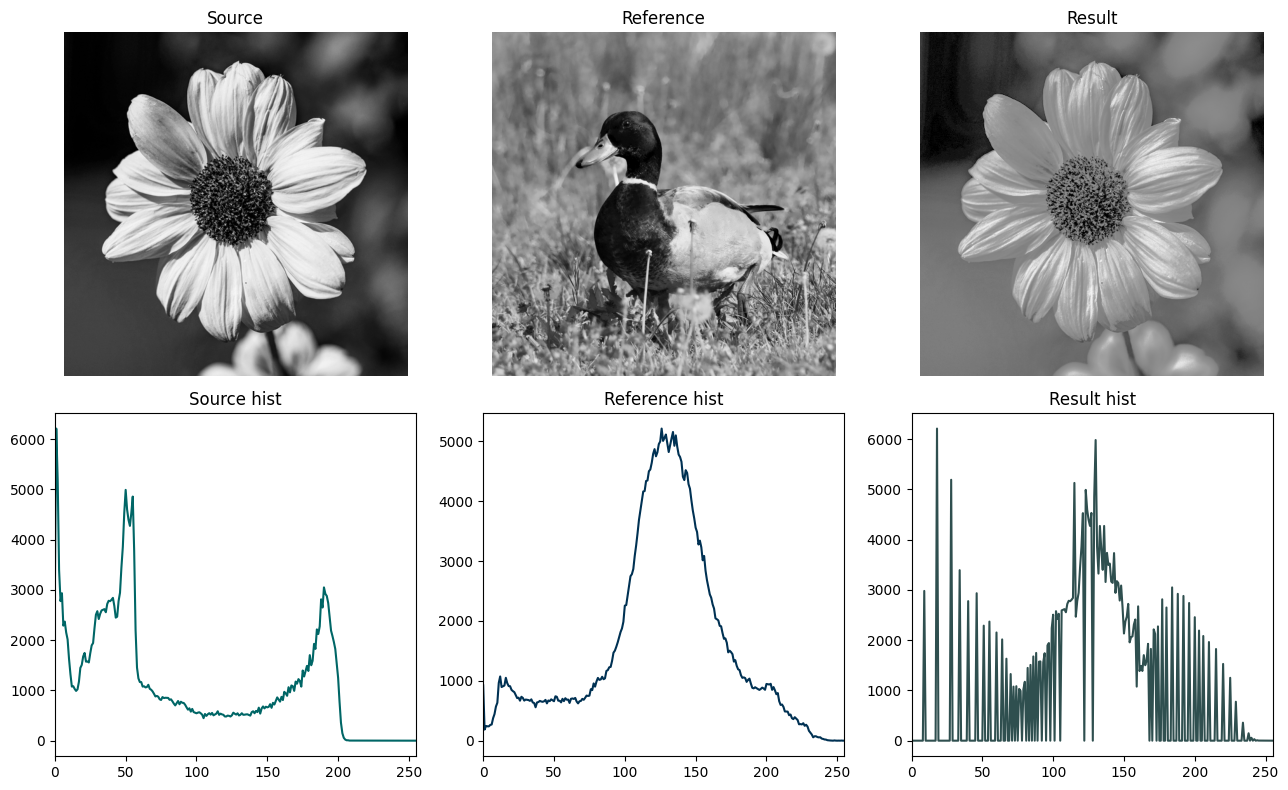

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, img, title in zip(
    axes[0], [src, ref, result], ["Source", "Reference", "Result"]
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

colors = ["#006666", "#003153", "#2F4F4F"]
for ax, img, title, c in zip(
    axes[1],
    [src, ref, result],
    ["Source hist", "Reference hist", "Result hist"],
    colors,
):
    h = cv2.calcHist([img], [0], None, [256], [0, 256])
    ax.plot(h, color=c)
    ax.set_title(title)
    ax.set_xlim([0, 255])

plt.tight_layout()
plt.show()